In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests
from io import BytesIO

In [2]:
model_url = "https://tfhub.dev/google/faster_rcnn/openimages_v4/inception_resnet_v2/1"
detector = hub.load(model_url).signatures['default']

In [4]:
path = '/content/195083.jpg'

img = Image.open(path).convert("RGB")
img_resized = img.resize((640, 480))

image_tensor = tf.convert_to_tensor(np.array(img_resized), dtype=tf.float32)[tf.newaxis, ...] / 255.0


In [5]:
result = detector(image_tensor)

boxes = result['detection_boxes'].numpy()
labels = result['detection_class_entities'].numpy()
scores = result['detection_scores'].numpy()

if boxes.ndim > 2:
    boxes = boxes[0]
    labels = labels[0]
    scores = scores[0]

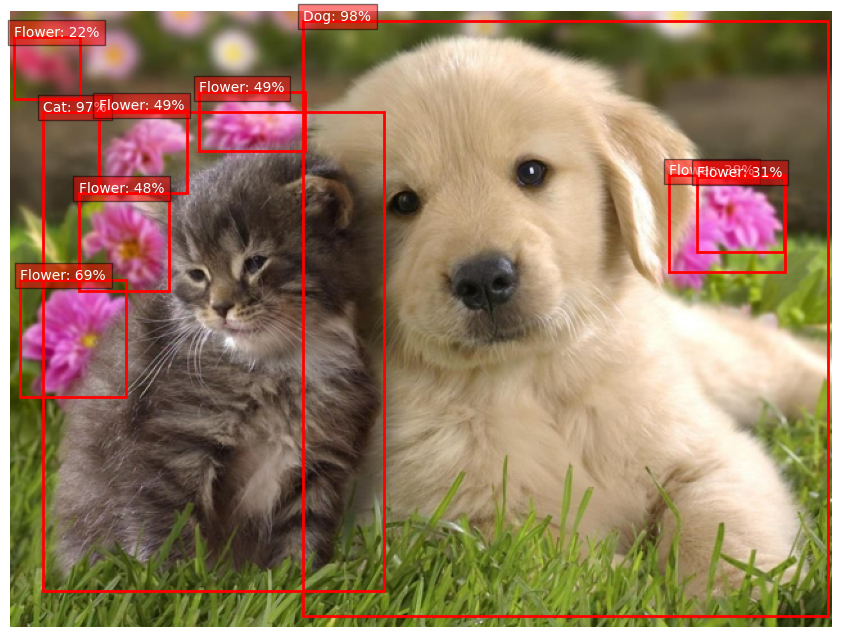

In [6]:
plt.figure(figsize=(12, 8))
plt.imshow(img_resized)
ax = plt.gca()

found_something = False
for i in range(len(scores)):
    if scores[i] > 0.2:
        found_something = True
        ymin, xmin, ymax, xmax = boxes[i]

        (left, right, top, bottom) = (xmin * 640, xmax * 640, ymin * 480, ymax * 480)

        rect = patches.Rectangle((left, top), right - left, bottom - top,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        name = labels[i].decode('utf-8')
        plt.text(left, top, f"{name}: {int(scores[i]*100)}%",
                 color='white', bbox=dict(facecolor='red', alpha=0.5))

plt.axis('off')
plt.show()


In [8]:
!pip install gtts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [9]:
from gtts import gTTS
import os
from IPython.display import Audio

detected_objects = list(set([labels[i].decode('utf-8') for i in range(len(scores)) if scores[i] > 0.3]))

if detected_objects:
    text_to_say = "I can see " + " and ".join(detected_objects)
    print(f"voice {text_to_say}")

    tts = gTTS(text=text_to_say, lang='en')
    tts.save("output.mp3")

    display(Audio("output.mp3", autoplay=True))
else:
    print("No objects detected to speak.")

voice I can see Cat and Dog and Flower


In [10]:
from gtts import gTTS
import os
from IPython.display import Audio

translation_dict = {
    'dog': 'كلب',
    'cat': 'قطة',
    'person': 'شخص',
    'car': 'سيارة',
    'bicycle': 'دراجة',
    'chair': 'كرسي',
    'table': 'طاولة',
    'bottle': 'زجاجة',
    'bird': 'طائر',
    'flower':'وردة'
}

detected_en = list(set([labels[i].decode('utf-8').lower() for i in range(len(scores)) if scores[i] > 0.3]))
detected_ar = [translation_dict.get(obj, obj) for obj in detected_en]

if detected_ar:
    text_to_say = "أنا أرى " + " و ".join(detected_ar)
    print(f"النطق: {text_to_say}")

    tts = gTTS(text=text_to_say, lang='ar')
    tts.save("output_ar.mp3")

    display(Audio("output_ar.mp3", autoplay=True))

النطق: أنا أرى وردة و كلب و قطة
